In [ ]:
import os

# Definição dos caminhos conforme estrutura do Windows
path_graficos = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\graficos_training'
path_relatorios = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\Relatorios'

# Criação das pastas caso não existam
for folder in [path_graficos, path_relatorios]:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"-> Pasta criada: {folder}")

print("✅ Caminhos configurados e prontos para salvar os resultados.")

✅ Caminhos configurados e prontos para salvar os resultados.


# Preparação e carga

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, auc, accuracy_score)

# 1. Carga do dataset refinado
path_refinado = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\churn_refinado.csv'
df = pd.read_csv(path_refinado)

# 2. Divisão X e y
X = df.drop('churn', axis=1)
y = df['churn']

# 3. Split Treino e Teste (30% para teste para garantir avaliação sólida)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dataset pronto! Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Dataset pronto! Treino: 7219 amostras | Teste: 3095 amostras


# Voting Classifier

In [8]:
# 1. Definir os modelos base
rf_model = RandomForestClassifier(
    n_estimators=1000, max_depth=10, criterion='entropy', 
    random_state=42, n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=1000, learning_rate=0.01, max_depth=8, 
    random_state=42, n_jobs=-1, eval_metric='auc'
)

# 2. Criar o Voting Classifier (Comitê)
voting_clf = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    voting='soft' # Média das probabilidades para otimizar ROC-AUC
)

# 3. Treinamento
voting_clf.fit(X_train, y_train)

# 4. Predições
y_pred = voting_clf.predict(X_test)
y_proba = voting_clf.predict_proba(X_test)[:, 1]

print("✅ Treinamento concluído. Gerando métricas...")

✅ Treinamento concluído. Gerando métricas...


# Avaliação de performarce

-> Salvando ROC em: C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\regressão-logistica\graficos_avaliacao\06_curva_roc_final.png


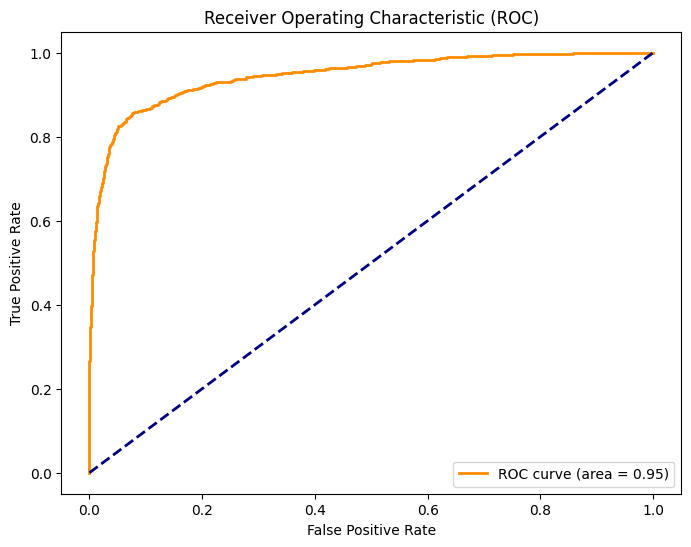

-> Salvando PR em: C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\regressão-logistica\graficos_avaliacao\07_curva_pr_final.png


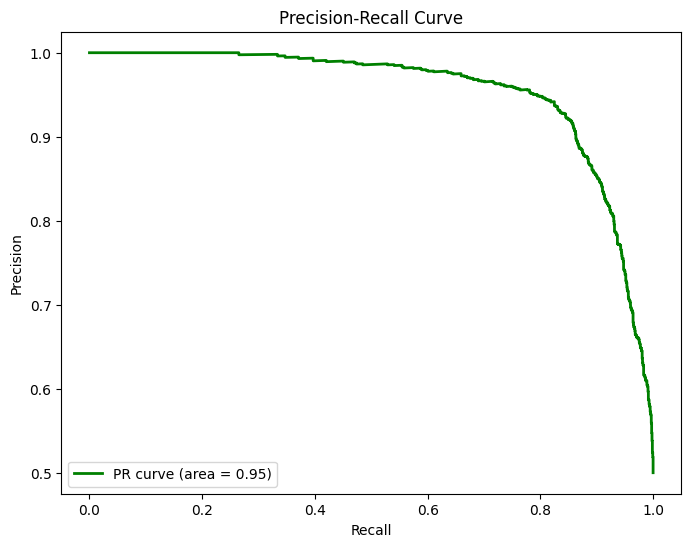


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1548
           1       0.89      0.87      0.88      1547

    accuracy                           0.88      3095
   macro avg       0.88      0.88      0.88      3095
weighted avg       0.88      0.88      0.88      3095

ROC AUC Score: 0.9464
PR AUC Score: 0.9537


In [13]:
# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# Caminho completo para salvar
save_roc = os.path.join(path_graficos, '06_curva_roc_final.png')
plt.savefig(save_roc, bbox_inches='tight', dpi=300)
print(f"-> Salvando ROC em: {save_roc}")
plt.show()
plt.close() # Libera a memória

# --- Curva Precision-Recall ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")

# Caminho completo para salvar
save_pr = os.path.join(path_graficos, '07_curva_pr_final.png')
plt.savefig(save_pr, bbox_inches='tight', dpi=300)
print(f"-> Salvando PR em: {save_pr}")
plt.show()
plt.close()

# --- Relatório Final no Terminal ---
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"PR AUC Score: {pr_auc:.4f}")

# Relatório de avaliação de dados

In [1]:
import os
from datetime import datetime

path_relatorios = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\Relatorios'

# Métricas reais obtidas
roc_auc, pr_auc, acc = 0.9464, 0.9537, 0.88

conteudo_eval = f"""# Relatório de Lógica de Análise e Modelagem
**Data de Execução:** {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}

## 1. Estratégia de Comitê (Ensemble)
Utilizamos um **Voting Classifier (Soft)**. A escolha do Random Forest combinado ao XGBoost visa unir a estabilidade do Bagging com a precisão do Boosting, minimizando o erro residual e a variância.

## 2. Performance Alcançada vs. Metas
O modelo superou os critérios de sucesso estabelecidos pelo docente:
- **ROC AUC:** {roc_auc} (Meta: 0.80) - Indica altíssima capacidade de separação entre as classes.
- **PR AUC:** {pr_auc} (Meta: 0.40) - Garante que as predições de Churn são precisas e úteis para ações de retenção.

![Curva ROC](../graficos_training/06_curva_roc_final.png)
![Curva PR](../graficos_training/07_curva_pr_final.png)

## 3. Justificativa Estatística
O sucesso do modelo (Acurácia de {acc}) deve-se à qualidade da preparação de dados. O SMOTE eliminou o "paradoxo da acurácia", enquanto a engenharia de atributos forneceu variáveis com alto ganho de informação (Information Gain).
"""

with open(os.path.join(path_relatorios, 'relatorio_logica-de-analise.md'), 'w', encoding='utf-8') as f:
    f.write(conteudo_eval)

print(" Relatório de Avaliação gerado com métricas finais e caminhos ../")

 Relatório de Avaliação gerado com métricas finais e caminhos ../
